In [1]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc"
GRID_NAME = "grid.csv"
PARAMS_NAME = "parameters.json"
EXP_NAME = "statistics"


In [3]:
def read_grid_csv(file_path):
    rows = []
    with open(file_path, "r", encoding="utf-8") as file:
        next(file)
        for line in file:
            line = line.strip()
            if not line:
                continue
            timestamp_text, value_text = line.split(",", 1)
            rows.append({
                "timestamp": float(timestamp_text),
                "grid_utilization": float(value_text.replace(",", "."))
            })
    return pd.DataFrame(rows)

def plot_grid_utilization(ax, file_path, label):
    df = read_grid_csv(file_path)
    df["hours"] = df["timestamp"] / 3600
    ax.plot(df["hours"], df["grid_utilization"], marker="o", label=label)
    ax.set_title("Grid utilization by hour")
    ax.set_xlabel("Hours")
    ax.set_ylabel("Grid utilization")
    ax.set_ylim(0, 1)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend()


found ['statistics_1']


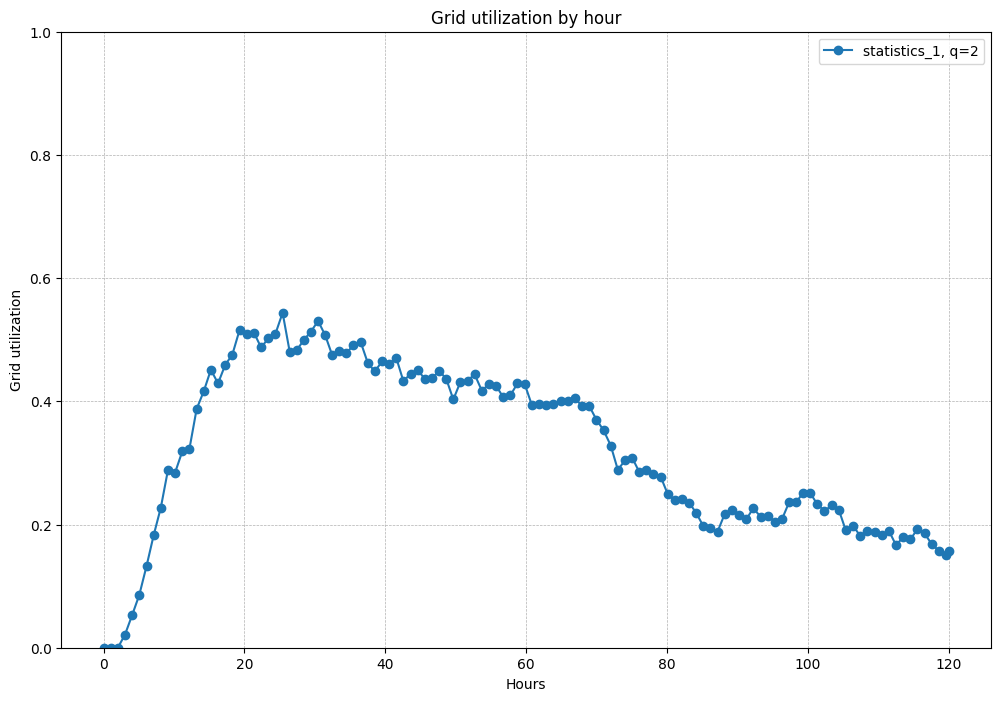

In [4]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

fig, ax = plt.subplots(figsize=(12, 8))

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    with open(os.path.join(full_path, PARAMS_NAME), "r", encoding="utf-8") as file:
        params = json.load(file)

    replication_value = params["ProjectConfig"]["TaskConfigs"][0]["InitialCreatedWorkunits"]
    label = f"{folder}, q={replication_value}"
    plot_grid_utilization(ax, os.path.join(full_path, GRID_NAME), label)

plt.show()
